---
## Phase 1 — Setup


# 🇦🇲 Armenian Handwritten OCR — Fixed Pipeline

Key fixes over previous version:
- **Balanced character coverage** — every Armenian letter appears ≥100x
- **IMG_HEIGHT=48** — cursive characters are too similar at 32px
- **Curriculum training** — clean images first, augmentation added gradually
- **LR warmup** — prevents CTC collapse in early epochs
- **Weighted word sampling** — rare characters are oversampled


In [18]:
import subprocess, sys
def pip(*p): subprocess.run([sys.executable,'-m','pip','install','-q',*p],check=True)
pip('ultralytics','huggingface_hub','editdistance','ipywidgets')
print('✅ Ready')


✅ Ready


In [19]:
import pandas as pd
Df=pd.read_csv('/kaggle/input/datasets/araksyag/labels-b-1205/labels_person_B (3) (3).csv') 
Df.to_csv('/kaggle/working/labels-b-1205.csv')

In [20]:
from huggingface_hub import snapshot_download
from pathlib import Path

print("📥 Downloading dataset...")
snapshot_download(
    repo_id="armvectores/handwritten_text_detection",
    repo_type="dataset",
    local_dir="/kaggle/working/handwritten_text_detection",
    ignore_patterns=["*.git*", ".gitattributes"],
)
print("✅ Done")

# Verify
for split in ["train", "test"]:
    p = Path(f"/kaggle/working/handwritten_text_detection/{split}")
    if p.exists():
        files = list(p.glob("*"))
        imgs = [f for f in files if f.suffix.lower() in {".jpg", ".png"}]
        txts = [f for f in files if f.suffix == ".txt"]
        print(f"  {split}: {len(imgs)} images, {len(txts)} label files")

📥 Downloading dataset...


Fetching 186 files:   0%|          | 0/186 [00:00<?, ?it/s]

✅ Done
  train: 0 images, 0 label files
  test: 0 images, 0 label files


In [21]:
import os, io, csv, json, random, base64, math
from pathlib import Path
from collections import Counter
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from tqdm.notebook import tqdm
import editdistance

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [22]:
from huggingface_hub import hf_hub_download
DETECTOR_PATH = hf_hub_download(
    repo_id='armvectores/yolov8n_handwritten_text_detection',
    filename='best.pt', local_dir='./models')
print(f'✅ Detector: {DETECTOR_PATH}')


✅ Detector: models/best.pt


---
## Phase 2 — Extract Word Crops


In [23]:
DATASET_DIR = Path('/kaggle/working/handwritten_text_detection')

def find_pairs(dataset_dir):
    pairs = []
    for split in ['train','test']:
        for img_dir, lbl_dir in [
            (dataset_dir/split, dataset_dir/split),
            (dataset_dir/split/'images', dataset_dir/split/'labels'),
        ]:
            imgs = sorted(list(img_dir.glob('*.jpg'))+list(img_dir.glob('*.png'))+
                          list(img_dir.glob('*.JPG'))+list(img_dir.glob('*.PNG')))
            if imgs:
                for ip in imgs:
                    lp = lbl_dir/(ip.stem+'.txt')
                    if lp.exists(): pairs.append((ip,lp,split))
                break
    return pairs

pairs = find_pairs(DATASET_DIR)
print(f'Found {len(pairs)} image/label pairs')
for s in ['train','test']:
    print(f'  {s}: {sum(1 for _,_,sp in pairs if sp==s)}')


Found 91 image/label pairs
  train: 73
  test: 18


In [24]:
def extract_word_crops(pairs, output_dir='./real_crops', padding=4):
    output_dir = Path(output_dir)
    records = []
    for img_path, lbl_path, split in tqdm(pairs, desc='Extracting'):
        (output_dir/split).mkdir(parents=True, exist_ok=True)
        img = Image.open(img_path).convert('RGB'); W,H = img.size
        with open(lbl_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        boxes = []
        for line in lines:
            p = line.split()
            if len(p)<5: continue
            _,cx,cy,bw,bh = map(float,p)
            x1,y1 = int((cx-bw/2)*W),int((cy-bh/2)*H)
            x2,y2 = int((cx+bw/2)*W),int((cy+bh/2)*H)
            boxes.append((round(y1/25),x1,y1,x2,y2))
        boxes.sort()
        for idx,(_,x1,y1,x2,y2) in enumerate(boxes):
            x1p,y1p = max(0,x1-padding),max(0,y1-padding)
            x2p,y2p = min(W,x2+padding),min(H,y2+padding)
            if x2p-x1p<5 or y2p-y1p<5: continue
            crop = img.crop((x1p,y1p,x2p,y2p))
            cp = output_dir/split/f'{img_path.stem}_w{idx:04d}.png'
            crop.save(str(cp))
            records.append({'crop_path':str(cp),'source_image':str(img_path),
                             'split':split,'text':''})
    return records

ALL_RECORDS = extract_word_crops(pairs)
print(f'✅ {len(ALL_RECORDS):,} crops extracted')
pd.DataFrame(ALL_RECORDS).to_csv('labels_template.csv', index=False)


Extracting:   0%|          | 0/91 [00:00<?, ?it/s]

✅ 11,425 crops extracted


---
## Phase 3 — Balanced Synthetic Data Generation

**Key fix:** every Armenian character is guaranteed to appear ≥100 times.
Words with rare characters are oversampled during generation.


In [25]:
from collections import Counter

# ── Balanced word list: Authentic Armenian vocabulary covering ALL characters ──
ARMENIAN_WORDS = [
    # ա - աչք, արև, աղոթք
    'աչք', 'արև', 'աղոթք', 'ազատություն', 'անուն', 'ամպ', 'ածանց', 'աշխարհ', 'առավոտ', 'արագ',
    # բ - բերան, բնություն, բարի
    'բերան', 'բնություն', 'բարձր', 'բազում', 'բարի', 'բակ', 'բախտ', 'բառարան', 'բույս', 'բժիշկ',
    # գ - գարուն, գիրք, գեղեցիկ
    'գարուն', 'գիրք', 'գլուխ', 'գեղեցիկ', 'գույն', 'գետ', 'գիտնական', 'գործ', 'գիշեր', 'գինի',
    # դ - դաշտ, դպրոց, դեղին
    'դաշտ', 'դպրոց', 'դեղին', 'դեմք', 'դասարան', 'դուռ', 'դրամ', 'դանդաղ', 'դատավոր', 'դանակ',
    # ե - երկիր, երգ, երազ
    'երկիր', 'երգ', 'երազ', 'ելակ', 'երբ', 'երեք', 'երկինք', 'երեկո', 'ելք', 'եղբայր',
    # զ - զանգ, զարդ, զորություն
    'զանգ', 'զարդ', 'զորություն', 'զգացմունք', 'զավակ', 'զվարթ', 'զարկերակ', 'զենք', 'զատիկ', 'զբոսայգի',
    # է - էջ, էակ, էություն
    'էջ', 'էակ', 'էություն', 'էկրան', 'էներգիա', 'էլեկտրոն', 'էշ', 'էպոս', 'էժան', 'էական',
    # ը - ընկեր, ընտանիք, ընթացք
    'ընկեր', 'ընտանիք', 'ընդհանուր', 'ըստ', 'ընթացք', 'ըմպելիք', 'ընդունել', 'ըղձալի', 'ընձուղտ', 'ընդարձակ',
    # թ - թուղթ, թռչուն, թագավոր
    'թուղթ', 'թռչուն', 'թագավոր', 'թույլ', 'թանկ', 'թեյ', 'թիվ', 'թարմ', 'թակարդ', 'թևավոր',
    # ժ - ժամանակ, ժպիտ, ժողովուրդ
    'ժամանակ', 'ժպիտ', 'ժողովուրդ', 'ժայռ', 'ժապավեն', 'ժանյակ', 'ժառանգություն', 'ժխտել', 'ժանտախտ', 'ժիր',
    # ի - իմաստ, իշխան, իրական
    'իմաստ', 'իշխան', 'իրական', 'ինչպես', 'ինքնաթիռ', 'իջնել', 'իսկույն', 'իրիկուն', 'իղձ', 'իգական',
    # լ - լույս, լեռ, լեզու
    'լույս', 'լեռ', 'լեզու', 'լավատես', 'լողալ', 'լիճ', 'լուրջ', 'լիակատար', 'լամպ', 'լոլիկ',
    # խ - խաղաղություն, խնձոր, խաչքար
    'խաղաղություն', 'խնձոր', 'խաչքար', 'խոսք', 'խելացի', 'խաղալիք', 'խոհանոց', 'խորը', 'խոտ', 'խաչմերուկ',
    # ծ - ծաղիկ, ծառ, ծիածան
    'ծաղիկ', 'ծառ', 'ծնող', 'ծով', 'ծիածան', 'ծանր', 'ծիծաղ', 'ծածկոց', 'ծիրան', 'ծանոթ',
    # կ - կամուրջ, կյանք, կատու
    'կամուրջ', 'կայարան', 'կապույտ', 'կյանք', 'կատու', 'կանաչ', 'կարմիր', 'կարող', 'կտոր', 'կայծակ',
    # հ - հայրենիք, հաց, հույս
    'հայրենիք', 'հաց', 'հույս', 'հրեշտակ', 'հնարավոր', 'հոգի', 'հեռախոս', 'հայելի', 'հարուստ', 'հարց',
    # ձ - ձայն, ձեռք, ձմեռ
    'ձայն', 'ձեռք', 'ձմեռ', 'ձկնորս', 'ձիավոր', 'ձագ', 'ձվարան', 'ձող', 'ձմերուկ', 'ձախ',
    # ղ - ղեկավար, ղողանջ, ղափամա
    'ղեկավար', 'ղողանջ', 'ղափամա', 'ղեկ', 'ղազախ', 'ղեկակալ', 'ղալա', 'ղարս', 'ղարաբաղ', 'ղեկավարություն',
    # ճ - ճանապարհ, ճաշակ, ճյուղ
    'ճանապարհ', 'ճաշակ', 'ճակատ', 'ճայ', 'ճյուղ', 'ճկուն', 'ճակատագիր', 'ճամպրուկ', 'ճշմարիտ', 'ճնշում',
    # մ - մայր, մարդ, մշակույթ
    'մայր', 'մարդ', 'մարմին', 'մշակույթ', 'մոմ', 'մուկ', 'մատիտ', 'մեքենա', 'միշտ', 'միրգ',
    # յ - յուղ, յոթ, յասաման
    'յուղ', 'յոթ', 'յասաման', 'յուրաքանչյուր', 'յուրահատուկ', 'յուրային', 'յարխուշտա', 'յուղամատիտ', 'յունիս', 'յոթանասուն',
    # ն - նավ, նարինջ, նվեր
    'նավ', 'նարինջ', 'նախագիծ', 'նորություն', 'նվեր', 'նկար', 'նամակ', 'նուրբ', 'նարեկացի', 'նպատակ',
    # շ - շուն, շաքար, շքեղ
    'շուն', 'շաքար', 'շնորհակալություն', 'շքեղ', 'շողք', 'շաբաթ', 'շուրջերկրյա', 'շնչառություն', 'շրջան', 'շուկա',
    # ո - ոտք, որակ, ողջույն
    'ոտք', 'որակ', 'ողջույն', 'որդի', 'ողնաշար', 'ոսկի', 'որսորդ', 'ոստիկան', 'ոչխար', 'ոգևորված',
    # չ - չափահաս, չորս, չամիչ
    'չափահաս', 'չորս', 'չամիչ', 'չարիք', 'չնաշխարհիկ', 'չմուշկ', 'չքավոր', 'չմոռանալ', 'չոր', 'չափանիշ',
    # պ - պապիկ, պատուհան, պետություն
    'պապիկ', 'պատուհան', 'պար', 'պետություն', 'պաշտպան', 'պատմություն', 'պատիվ', 'պայուսակ', 'պարզ', 'պայթյուն',
    # ջ - ջուր, ջերմություն, ջութակ
    'ջուր', 'ջերմություն', 'ջութակ', 'ջահ', 'ջրանցք', 'ջինջ', 'ջնջել', 'ջոկատ', 'ջանք', 'ջրվեժ',
    # ռ - ռազմիկ, ռադիո, ռոբոտ
    'ռազմիկ', 'ռադիո', 'ռոբոտ', 'ռետին', 'ռուսաստան', 'ռումբ', 'ռելիեֆ', 'ռիթմ', 'ռեստորան', 'ռահվիրա',
    # ս - սեր, սեղան, սիրտ
    'սեր', 'սեղան', 'սպիտակ', 'սահման', 'սիրտ', 'սար', 'սառույց', 'սովորել', 'սունկ', 'սնունդ',
    # վ - վարդ, վազք, վճար
    'վարդ', 'վազք', 'վերնաշապիկ', 'վճար', 'վստահություն', 'վայրկյան', 'վաղը', 'վատ', 'վտանգ', 'վերև',
    # տ - տուն, տատիկ, տարի
    'տուն', 'տատիկ', 'տաղանդ', 'տոն', 'տարի', 'տերև', 'տաք', 'տեսարան', 'տղա', 'տպավորություն',
    # ր - րոպե, լուր, սուր (ր is rarely word-initial, but occurs in middle/end)
    'րոպե', 'լուր', 'սուր', 'հարյուր', 'մարտ', 'դասարան', 'բարձր', 'դար', 'գրիչ', 'հարց',
    # ց - ցորեն, ցանկություն, ցավ
    'ցորեն', 'ցանկություն', 'ցավ', 'ցուցակ', 'ցուրտ', 'ցողուն', 'ցանկապատ', 'ցատկել', 'ցերեկ', 'ցուցահանդես',
    # ւ - նաւ (Used in 'ու' combinations or classic orthography)
    'ուժ', 'ուսուցիչ', 'ուղեղ', 'ուսում', 'ուտել', 'ուրախ', 'ուղիղ', 'ուրիշ', 'ութ', 'ուրբաթ',
    # փ - փողոց, փոքր, փայտ
    'փողոց', 'փոքր', 'փայտ', 'փառք', 'փոխել', 'փեսա', 'փոշի', 'փչել', 'փառատոն', 'փոթորիկ',
    # ք - քաղաք, քույր, քամի
    'քաղաք', 'քույր', 'քամի', 'քարտեզ', 'քայլ', 'քաղցր', 'քննություն', 'քար', 'քիթ', 'քառակուսի',
    # օ - օդ, օրենք, օգնություն
    'օդ', 'օրենք', 'օգնություն', 'օգոստոս', 'օծանելիք', 'օրինակ', 'օղակ', 'օվկիանոս', 'օտար', 'օրորոց',
    # ֆ - ֆիլմ, ֆուտբոլ, ֆաբրիկա
    'ֆիլմ', 'ֆուտբոլ', 'ֆաբրիկա', 'ֆլեյտա', 'ֆրանսերեն', 'ֆերմեր', 'ֆիզիկա', 'ֆոնդ', 'ֆինանսներ', 'ֆորմալ',
]
# Also add real Armenian words
REAL_WORDS = [
    'բարև','բարի','օր','գիշեր','լույս','երեկո','կեսօր','ցտեսություն',
    'շնորհակալ','խնդրեմ','ներողություն','այո','ոչ','լավ','վատ',
    'մայր','հայր','եղբայր','քույր','տատ','պապ','տղա','աղջիկ',
    'մարդ','կին','երեխա','ընկեր','ընտանիք','ժողովուրդ','մարդիկ',
    'արև','լուսին','աստղ','երկինք','ամպ','անձրև','ձյուն','քամի',
    'ծով','գետ','լիճ','լեռ','ծառ','ծաղիկ','խոտ','անտառ','դաշտ',
    'հող','ջուր','կրակ','օդ','քար','ավազ','հողմ',
    'կարմիր','կանաչ','կապույտ','դեղին','սպիտակ','սև',
    'մեկ','երկու','երեք','չորս','հինգ','վեց','յոթ','ութ','ինը','տաս',
    'հաց','ջուր','կաթ','մրգ','ձուկ','հավ','գինի','թեյ','սուրճ','շաքար',
    'Հայաստան','Երևան','Գյումրի','Վանաձոր','Արարատ','Սևան',
    'տուն','փողոց','քաղաք','գյուղ','երկիր','դպրոց','խանութ','բժշկարան',
    'գլուխ','ձեռք','ոտք','աչք','ականջ','բերան','քիթ','մատ','սիրտ',
    'ուղեղ','ատամ','շուրթ','դեմք','մազ','մարմին','ձայն',
    'օր','գիշեր','շաբաթ','ամիս','տարի','ժամ','րոպե','վայրկյան',
    'երեկ','այսօր','վաղը','անցյալ','ներկա','ապագա','առավոտ',
    'գնալ','գալ','տեսնել','ասել','լսել','կարդալ','գրել','ուտել',
    'խմել','քնել','արթնանալ','վազել','քայլել','խոսել','լալ','ծիծաղել',
    'սիրել','ատել','ուզել','կարողանալ','հասկանալ','մտածել',
    'մեծ','փոքր','երկար','կարճ','հաստ','բարակ','ծանր','թեթև',
    'արագ','դանդաղ','ուժեղ','թույլ','խելացի','գեղեցիկ',
    'ջերմ','սառ','թարմ','հին','նոր','ազատ','ուրախ','տխուր','հոգնած',
    'գիրք','թուղթ','մատիտ','գրիչ','սեղան','աթոռ','դուռ','պատուհան',
    'ճանապարհ','կամուրջ','մեքենա','հեռախոս','ժամացույց','դրամ',
    'ձի','շուն','կատու','թռչուն','կով','ոչխար','հավ','արջ',
    'ու','եւ','կամ','նաև','բայց','որ','եթե','թե','մի','ես','դու',
    'նա','մենք','դուք','նրանք','իմ','քո','նրա','մեր','ձեր',
    'ամեն','ամբողջ','շատ','քիչ','ավելի','պակաս','շուտ','ուշ',
    'հիմա','հետո','արդեն','դեռ','անգամ','ճիշտ',
    'համալսարան','հանրապետություն','անկախություն','պատմություն',
    'հասարակություն','արվեստ','գրականություն','երաժշտություն',
    'հայկական','հայոց','հայերեն','կրթություն','առողջություն',
    'ազատություն','խաղաղություն','պատերազմ','հաղթանակ',
    'Արարատ','Ուրարտու','Արտաշատ','Ծաղկաձոր','Դիլիջան',
    'Աստված','եկեղեցի','աղոթք','հավատ','սուրբ','խաչ',
    'բժիշկ','ուսուցիչ','ճարտարագետ','իրավաբան','ճարտարապետ',
    'դերասան','երգիչ','նկարիչ','բանաստեղծ','գրող','լրագրող',
]

ALL_WORDS = list(dict.fromkeys(
    [w.strip() for w in ARMENIAN_WORDS + REAL_WORDS if w.strip()]
))

# Diagnose coverage
arm_lower = 'աբգդեզէըթժիլխծկհձղճմյնշոչպջռսվտրցւփքևօֆ'
all_text  = ''.join(ALL_WORDS)
counts    = Counter(all_text)
min_count = min(counts.get(c,0) for c in arm_lower)
print(f'Word list size: {len(ALL_WORDS)}')
print(f'Min character count: {min_count}')
rare = [c for c in arm_lower if counts.get(c,0) < 20]
print(f'Still rare (<20 occurrences): {rare}')
print('Character counts:')
for ch in arm_lower:
    n = counts.get(ch,0)
    bar = '█' * min(n//3,30)
    flag = ' ⚠' if n<20 else ''
    print(f'  {ch} {n:4d}  {bar}{flag}')


Word list size: 542
Min character count: 10
Still rare (<20 occurrences): ['է', 'ը', 'ժ', 'ճ', 'փ', 'և', 'օ', 'ֆ']
Character counts:
  ա  470  ██████████████████████████████
  բ   29  █████████
  գ   43  ██████████████
  դ   36  ████████████
  ե  147  ██████████████████████████████
  զ   26  ████████
  է   10  ███ ⚠
  ը   13  ████ ⚠
  թ   65  █████████████████████
  ժ   19  ██████ ⚠
  ի  120  ██████████████████████████████
  լ   75  █████████████████████████
  խ   33  ███████████
  ծ   26  ████████
  կ  127  ██████████████████████████████
  հ   45  ███████████████
  ձ   23  ███████
  ղ   68  ██████████████████████
  ճ   17  █████ ⚠
  մ   76  █████████████████████████
  յ   88  █████████████████████████████
  ն  216  ██████████████████████████████
  շ   40  █████████████
  ո  263  ██████████████████████████████
  չ   28  █████████
  պ   36  ████████████
  ջ   28  █████████
  ռ   33  ███████████
  ս   78  ██████████████████████████
  վ   48  ████████████████
  տ  110  ███████████████████

In [26]:
# ── Compute word sampling weights (rare-char words get higher weight) ─────
arm_lower = 'աբգդեզէըթժիլխծկհձղճմյնշոչպջռսվտրցւփքևօֆ'
all_text  = ''.join(ALL_WORDS)
char_freq = Counter(all_text)

def word_weight(word):
    """Words containing rare characters get higher sampling weight."""
    if not word: return 1.0
    # Weight = sum of (1/char_freq) for each char in word
    rarity = sum(1.0 / max(char_freq.get(c,1), 1) for c in word if c in arm_lower)
    return max(rarity, 0.1)

WORD_WEIGHTS = np.array([word_weight(w) for w in ALL_WORDS], dtype=np.float32)
WORD_WEIGHTS /= WORD_WEIGHTS.sum()

print(f'Top 5 highest-weight words (rare chars):')
top_idx = WORD_WEIGHTS.argsort()[-5:][::-1]
for i in top_idx:
    print(f'  {ALL_WORDS[i]:<30} weight={WORD_WEIGHTS[i]:.5f}')
print(f'Bottom 5 (common chars):')
bot_idx = WORD_WEIGHTS.argsort()[:5]
for i in bot_idx:
    print(f'  {ALL_WORDS[i]:<30} weight={WORD_WEIGHTS[i]:.5f}')


Top 5 highest-weight words (rare chars):
  ոգևորված                       weight=0.00314
  օծանելիք                       weight=0.00296
  ընդարձակ                       weight=0.00296
  ժառանգություն                  weight=0.00291
  ըմպելիք                        weight=0.00288
Bottom 5 (common chars):
  ուտել                          weight=0.00175
  քննություն                     weight=0.00175
  քաղցր                          weight=0.00175
  քայլ                           weight=0.00175
  քարտեզ                         weight=0.00175


In [27]:
# ── Augmentation ──────────────────────────────────────────────────────────
def elastic_distort(arr, alpha, sigma):
    h,w = arr.shape[:2]
    dx  = np.random.randn(h,w).astype(np.float32)*alpha
    dy  = np.random.randn(h,w).astype(np.float32)*alpha
    k   = int(sigma*2+1)
    for _ in range(3):
        dx = np.convolve(dx.ravel(),np.ones(k)/k,mode='same').reshape(h,w)
        dy = np.convolve(dy.ravel(),np.ones(k)/k,mode='same').reshape(h,w)
    xs,ys = np.meshgrid(np.arange(w),np.arange(h))
    mx = np.clip(xs+dx,0,w-1).astype(np.int32)
    my = np.clip(ys+dy,0,h-1).astype(np.int32)
    return arr[my,mx]

def augment(img, strength=1.0):
    if strength <= 0: return img
    arr = np.array(img.convert('L'))
    if random.random() < 0.8*strength:
        arr = elastic_distort(arr,
                              alpha=random.uniform(0.2,0.8)*strength,
                              sigma=random.uniform(2.0,4.0))
    if random.random() < 0.6*strength:
        arr = np.clip(arr+np.random.normal(0,random.uniform(1,5)*strength,arr.shape),
                      0,255).astype(np.uint8)
    img = Image.fromarray(arr)
    if random.random() < 0.7*strength:
        img = img.rotate(random.uniform(-3,3)*strength,fillcolor=255,expand=False)
    if random.random() < 0.4*strength:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2,0.7)))
    arr = np.clip(np.array(img,dtype=np.float32)*random.uniform(0.88,1.12)
                  +random.uniform(-10,10)*strength,0,255).astype(np.uint8)
    return Image.fromarray(arr)

def render_word(word, font, pad_x=8, pad_y=6):
    dummy = ImageDraw.Draw(Image.new('L',(1,1)))
    bb    = dummy.textbbox((0,0), word, font=font)
    W,H   = max(bb[2]-bb[0]+pad_x*2,10), max(bb[3]-bb[1]+pad_y*2,10)
    img   = Image.new('L',(W,H),color=255)
    ImageDraw.Draw(img).text(
        (pad_x-bb[0]+random.randint(-2,2), pad_y-bb[1]+random.randint(-1,1)),
        word, font=font, fill=0)
    return img

print('✅ Augmentation helpers ready')


✅ Augmentation helpers ready


In [28]:
# ── Generate dataset ───────────────────────────────────────────────────────
FONT_PATH  = '/kaggle/input/datasets/alengevorgyan/handwrittent-font/poqrik.ttf'
SYNTH_DIR  = Path('./synth_dataset')
N_SAMPLES  = 20000
# IMG_HEIGHT is set in Phase 5 — use 48 instead of 32
FONT_SIZES = [32, 36, 40, 44, 48]   # bigger = higher res crops at H=48
random.seed(42); np.random.seed(42)

if not Path(FONT_PATH).exists():
    raise FileNotFoundError(f'Upload poqrik.ttf to /kaggle/working/')

fonts = {sz: ImageFont.truetype(FONT_PATH, sz) for sz in FONT_SIZES}
(SYNTH_DIR/'images'/'train').mkdir(parents=True, exist_ok=True)
(SYNTH_DIR/'images'/'val').mkdir(parents=True,   exist_ok=True)

# 3 augmentation tiers mixed into train set
# clean 30% | mild 40% | medium 30%
AUG_TIERS = [(0.0, 0.30), (0.25, 0.40), (0.55, 0.30)]

n_val   = max(200, int(N_SAMPLES*0.10))
n_train = N_SAMPLES - n_val
synth_records = []

for split, n_split in [('train', n_train), ('val', n_val)]:
    out_dir = SYNTH_DIR/'images'/split
    print(f'Generating {n_split:,} {split} samples...')
    for i in tqdm(range(n_split)):
        # Weighted word selection
        word_idx = np.random.choice(len(ALL_WORDS), p=WORD_WEIGHTS)
        word     = ALL_WORDS[word_idx]
        img      = render_word(word, fonts[random.choice(FONT_SIZES)])
        if split == 'train':
            # Pick augmentation tier
            tier_r = random.random()
            cum = 0
            for strength, prob in AUG_TIERS:
                cum += prob
                if tier_r < cum: break
            img = augment(img, strength=strength)
        fname = f'{split}_{i:06d}.png'
        img.save(str(out_dir/fname))
        synth_records.append({'crop_path': str(out_dir/fname),
                               'text': word, 'split': split})

pd.DataFrame(synth_records).to_csv(SYNTH_DIR/'labels.csv', index=False)
print(f'\n✅ {len(synth_records):,} synthetic samples generated')

# Verify character coverage in generated data
gen_text  = ''.join(r['text'] for r in synth_records)
gen_counts= Counter(gen_text)
rare_after= [c for c in arm_lower if gen_counts.get(c,0) < 50]
print(f'Characters still rare (<50 appearances): {rare_after if rare_after else "None ✓"}')


Generating 18,000 train samples...


  0%|          | 0/18000 [00:00<?, ?it/s]

Generating 2,000 val samples...


  0%|          | 0/2000 [00:00<?, ?it/s]


✅ 20,000 synthetic samples generated
Characters still rare (<50 appearances): None ✓


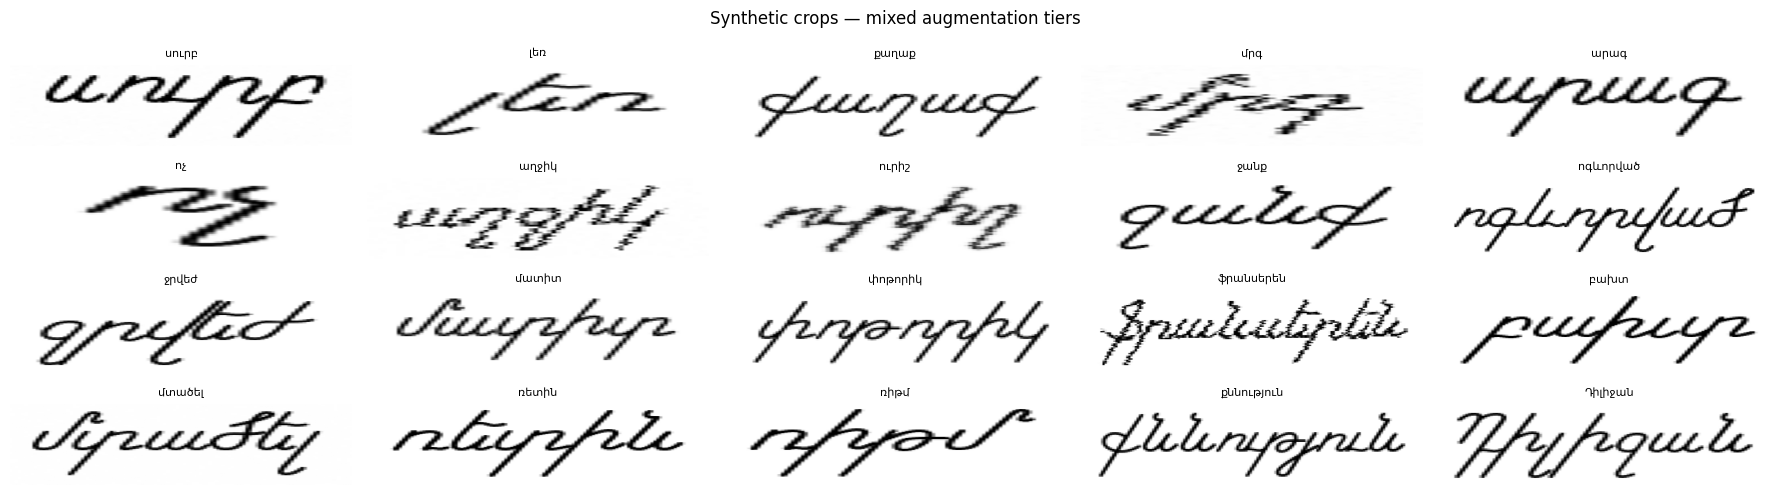

In [29]:
# Preview
samples = random.sample(synth_records, 20)
fig, axes = plt.subplots(4, 5, figsize=(18, 5))
for ax, rec in zip(axes.flatten(), samples):
    ax.imshow(Image.open(rec['crop_path']).convert('L'), cmap='gray', aspect='auto')
    ax.set_title(rec['text'], fontsize=8); ax.axis('off')
plt.suptitle('Synthetic crops — mixed augmentation tiers', fontsize=12)
plt.tight_layout(); plt.show()


---
## Phase 4 — Optional: Label Real Crops ✏️
Skip this phase if you want to train on synthetic data only.


In [9]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io, base64
from pathlib import Path
from PIL import Image
import pandas as pd

# ══════════════════════════════════════════════════════════════
# CHANGE THIS before running — each person sets their own name
PERSON = 'B'   # Person A sets 'A', Person B sets 'B'
# ══════════════════════════════════════════════════════════════

PROGRESS_CSV = f'/kaggle/working/labels-b-1205.csv'

# Load existing progress for this person
if Path(PROGRESS_CSV).exists():
    _saved = pd.read_csv(PROGRESS_CSV)
else:
    _saved = pd.DataFrame(columns=['crop_path', 'text'])

labeled_paths = set(_saved['crop_path'].tolist())

# Split ALL_RECORDS in half — A gets first half, B gets second half
midpoint  = len(ALL_RECORDS) // 2
my_crops  = ALL_RECORDS[:midpoint] if PERSON == 'A' else ALL_RECORDS[midpoint:]
unlabeled = [r for r in my_crops if r['crop_path'] not in labeled_paths]
labeled_data = _saved.to_dict('records')

print(f'Person {PERSON} — assigned crops: {len(my_crops):,}')
print(f'Already labeled: {len(labeled_paths):,}')
print(f'Remaining:       {len(unlabeled):,}')

# ── UI ────────────────────────────────────────────────────────
def _save():
    pd.DataFrame(labeled_data).to_csv(PROGRESS_CSV, index=False)

cur = [0]
img_out  = widgets.Output(layout=widgets.Layout(width='500px', min_height='80px'))
txt_in   = widgets.Text(placeholder='Type Armenian text…',
                         layout=widgets.Layout(width='360px'))
btn_ok   = widgets.Button(description='Submit ▶', button_style='success')
btn_skip = widgets.Button(description='Skip ⏩',  button_style='warning')
btn_bad  = widgets.Button(description='Unclear ✗', button_style='danger')
pbar     = widgets.IntProgress(value=0, min=0, max=max(len(unlabeled), 1),
                                description=f'{PERSON}:',
                                style={'bar_color': '#2ecc71' if PERSON=='A' else '#3498db'})
ctr      = widgets.Label()

def _refresh():
    if cur[0] >= len(unlabeled):
        with img_out:
            clear_output()
            print(f'✅ Person {PERSON} finished all crops! Download {PROGRESS_CSV}')
        return
    rec = unlabeled[cur[0]]
    img = Image.open(rec['crop_path']).convert('RGB')
    sc  = max(1, 90 // max(img.height, 1))
    img = img.resize((img.width * sc, img.height * sc), Image.NEAREST)
    buf = io.BytesIO(); img.save(buf, format='PNG')
    b64 = base64.b64encode(buf.getvalue()).decode()
    with img_out:
        clear_output(wait=True)
        display(widgets.HTML(
            f'<div style="text-align:center;padding:8px">'
            f'<img src="data:image/png;base64,{b64}" '
            f'style="border:2px solid #555;image-rendering:pixelated"/>'
            f'<p style="color:#888;font-size:11px;margin:2px">'
            f'Person {PERSON} — {Path(rec["crop_path"]).name}</p></div>'
        ))
    ctr.value = f'{cur[0]+1} / {len(unlabeled)}'
    pbar.value = cur[0]

def _submit(b=None):
    if cur[0] >= len(unlabeled): return
    if txt_in.value.strip():
        labeled_data.append({'crop_path': unlabeled[cur[0]]['crop_path'],
                              'text': txt_in.value.strip()})
        _save()
    txt_in.value = ''; cur[0] += 1; _refresh()

def _skip(b):  txt_in.value = ''; cur[0] += 1; _refresh()
def _bad(b):
    labeled_data.append({'crop_path': unlabeled[cur[0]]['crop_path'], 'text': 'UNCLEAR'})
    _save(); txt_in.value = ''; cur[0] += 1; _refresh()

txt_in.on_submit(_submit)
btn_ok.on_click(_submit)
btn_skip.on_click(_skip)
btn_bad.on_click(_bad)

_refresh()
display(img_out)
display(widgets.HBox([txt_in, btn_ok, btn_skip, btn_bad]))
display(widgets.HBox([pbar, ctr]))

Person B — assigned crops: 5,713
Already labeled: 2,814
Remaining:       2,899


/tmp/ipykernel_57/3689531450.py:86: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  txt_in.on_submit(_submit)


Output(layout=Layout(min_height='80px', width='500px'))

In [16]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io, base64, pandas as pd
from pathlib import Path
from PIL import Image

# ══════════════════════════════════════════════════════════════
# ↓ Change these paths to your CSV files
CSV_A = '/kaggle/input/datasets/araksyag/des-den/labels_verified (1).csv'
# ══════════════════════════════════════════════════════════════

# ── Load & merge ───────────────────────────────────────────────
df = pd.read_csv(CSV_A)
df   = df[df['text'].notna()].reset_index(drop=True)

# Fix relative paths
df['crop_path'] = df['crop_path'].apply(
    lambda p: str(Path('/kaggle/working') / p)
              if not str(p).startswith('/') else p
)

# Track which rows were edited
df['edited'] = False

# ── Helper: image → base64 ─────────────────────────────────────
def img_to_b64(path, target_h=80):
    try:
        img = Image.open(path).convert('RGB')
        w, h = img.size
        scale = max(1, target_h // h)
        img = img.resize((w * scale, h * scale), Image.NEAREST)
        buf = io.BytesIO()
        img.save(buf, format='PNG')
        return base64.b64encode(buf.getvalue()).decode()
    except Exception as e:
        return None

# ── State ──────────────────────────────────────────────────────
cur  = [0]
mode = ['all']   # 'all' or 'edited'

# ── Widgets ────────────────────────────────────────────────────
img_out    = widgets.Output(layout=widgets.Layout(
                 width='420px', min_height='120px'))

info_label = widgets.HTML()
txt_in     = widgets.Text(layout=widgets.Layout(width='380px'))
btn_save   = widgets.Button(description='✔ Save',
                             button_style='success',
                             layout=widgets.Layout(width='100px'))
btn_skip   = widgets.Button(description='▶ Next',
                             button_style='primary',
                             layout=widgets.Layout(width='100px'))
btn_prev   = widgets.Button(description='◀ Prev',
                             button_style='',
                             layout=widgets.Layout(width='100px'))
btn_delete = widgets.Button(description='✖ Delete',
                             button_style='danger',
                             layout=widgets.Layout(width='100px'))

progress   = widgets.IntProgress(
                 min=0, max=len(df)-1,
                 layout=widgets.Layout(width='400px'),
                 style={'bar_color': '#27ae60'})
counter    = widgets.Label()
edited_lbl = widgets.Label(value='Edited: 0')

# ── Render current sample ──────────────────────────────────────
def refresh():
    idx = cur[0]
    if idx < 0 or idx >= len(df):
        with img_out:
            clear_output()
            print('✅ All done!')
        return

    row   = df.iloc[idx]
    b64   = img_to_b64(row['crop_path'])
    label = str(row['text'])
    src   = row['source']
    ed    = '✏️ edited' if row['edited'] else ''

    # Update image panel
    with img_out:
        clear_output(wait=True)
        if b64:
            display(widgets.HTML(
                f'<div style="text-align:center;padding:6px;'
                f'background:#f8f8f8;border-radius:8px">'
                f'<img src="data:image/png;base64,{b64}" '
                f'style="border:2px solid #ccc;border-radius:4px;'
                f'image-rendering:pixelated;max-width:400px"/>'
                f'<p style="color:#999;font-size:10px;margin:4px 0 0">'
                f'{Path(row["crop_path"]).name}</p>'
                f'</div>'
            ))
        else:
            display(widgets.HTML(
                '<p style="color:red">⚠ Image not found</p>'))

    # Update info
    info_label.value = (
        f'<span style="font-size:13px">'
        f'<b>#{idx+1}/{len(df)}</b> &nbsp;|&nbsp; '
        f'Person <b>{src}</b> &nbsp;|&nbsp; '
        f'<span style="color:#e67e22">{ed}</span>'
        f'</span>'
    )

    # Pre-fill text box with current label
    txt_in.value     = label
    progress.value   = idx
    counter.value    = f'{idx+1} / {len(df)}'
    edited_lbl.value = f'Edited: {df["edited"].sum()}'

def save_and_next(b=None):
    idx      = cur[0]
    new_text = txt_in.value.strip()
    if new_text and new_text != str(df.at[idx, 'text']):
        df.at[idx, 'text']   = new_text
        df.at[idx, 'edited'] = True
        _autosave()
    cur[0] = min(cur[0] + 1, len(df) - 1)
    refresh()

def prev_sample(b):
    cur[0] = max(cur[0] - 1, 0)
    refresh()

def skip(b):
    cur[0] = min(cur[0] + 1, len(df) - 1)
    refresh()

def delete_sample(b):
    idx = cur[0]
    df.drop(index=idx, inplace=True)
    df.reset_index(drop=True, inplace=True)
    progress.max = max(len(df) - 1, 1)
    cur[0] = min(cur[0], len(df) - 1)
    _autosave()
    refresh()

def _autosave():
    """Save corrected labels back to both CSVs automatically."""
    a_rows = df[df['source'] == 'A'][['crop_path', 'text']]
    b_rows = df[df['source'] == 'B'][['crop_path', 'text']]

    # Restore relative paths before saving
    def to_relative(p):
        p = str(p)
        prefix = '/kaggle/working/'
        return p[len(prefix):] if p.startswith(prefix) else p

    a_rows = a_rows.copy(); a_rows['crop_path'] = a_rows['crop_path'].apply(to_relative)
    b_rows = b_rows.copy(); b_rows['crop_path'] = b_rows['crop_path'].apply(to_relative)

    a_rows.to_csv(CSV_A, index=False)
    b_rows.to_csv(CSV_B, index=False)

    # Also save merged
    merged = df[['crop_path', 'text']].copy()
    merged['crop_path'] = merged['crop_path'].apply(to_relative)
    merged.to_csv('/kaggle/working/labels_verified.csv', index=False)

# Also save on Enter key
txt_in.on_submit(save_and_next)
btn_save.on_click(save_and_next)
btn_skip.on_click(skip)
btn_prev.on_click(prev_sample)
btn_delete.on_click(delete_sample)

# ── Layout ─────────────────────────────────────────────────────
display(widgets.HTML('<h3 style="font-family:sans-serif">🔍 Label Verification Tool</h3>'))
display(info_label)
display(img_out)
display(widgets.HTML('<p style="font-size:12px;color:#666;margin:4px 0">'
                     'Edit the label below if wrong, then press Save or Enter.</p>'))
display(widgets.HBox([txt_in, btn_save]))
display(widgets.HBox([btn_prev, btn_skip, btn_delete]))
display(widgets.HBox([progress, counter, edited_lbl]))

refresh()

/tmp/ipykernel_57/1393036544.py:166: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  txt_in.on_submit(save_and_next)


HTML(value='<h3 style="font-family:sans-serif">🔍 Label Verification Tool</h3>')

HTML(value='')

Output(layout=Layout(min_height='120px', width='420px'))

HTML(value='<p style="font-size:12px;color:#666;margin:4px 0">Edit the label below if wrong, then press Save o…

In [17]:
df.to_csv("/kaggle/working/labels_aaa.csv")

---
## Phase 5 — Train CRNN


In [30]:
# ── Merge data ─────────────────────────────────────────────────────────────
synth_df = pd.read_csv(SYNTH_DIR/'labels.csv')

if Path('labels_progress.csv').exists():
    manual_df = pd.read_csv('labels_progress.csv')
    manual_df = manual_df[
        manual_df['text'].notna() &
        (manual_df['text'].str.strip()!='') &
        (manual_df['text']!='UNCLEAR')
    ]
    rec_df    = pd.DataFrame(ALL_RECORDS)[['crop_path','split']]
    manual_df = manual_df.merge(rec_df, on='crop_path', how='left')
    manual_df['split'] = manual_df['split'].fillna('train')
    labels_df = pd.concat([synth_df,manual_df], ignore_index=True)
    print(f'Merged: {len(synth_df):,} synthetic + {len(manual_df):,} manual = {len(labels_df):,}')
else:
    labels_df = synth_df
    print(f'Synthetic only: {len(labels_df):,} samples')

train_df = labels_df[labels_df['split']=='train'].sample(frac=1,random_state=42).reset_index(drop=True)
val_df   = labels_df[labels_df['split']=='val'].sample(frac=1,  random_state=42).reset_index(drop=True)
print(f'Train: {len(train_df):,}  |  Val: {len(val_df):,}')


Synthetic only: 20,000 samples
Train: 18,000  |  Val: 2,000


In [31]:
# ── Alphabet & tokenizer ───────────────────────────────────────────────────
ARMENIAN_LOWER = 'աբգդեզէըթժիլխծկհձղճմյնշոչպջռսվտրցւփքևօֆ'
ARMENIAN_UPPER = 'ԱԲԳԴԵԶԷԸԹԺԻԼԽԾԿՀՁՂՃՄՅՆՇՈՉՊՋՌՍՎՏՐՑՒՓՔՕՖ'
ALL_CHARS = ARMENIAN_LOWER + ARMENIAN_UPPER

class CTCTokenizer:
    def __init__(self, alphabet):
        self.blank_idx   = 0
        self.char2idx    = {ch:i+1 for i,ch in enumerate(alphabet)}
        self.idx2char    = {i+1:ch for i,ch in enumerate(alphabet)}
        self.num_classes = len(alphabet)+1
    def encode(self, text):
        return [self.char2idx[c] for c in str(text) if c in self.char2idx]
    def decode(self, indices):
        out,prev = [],self.blank_idx
        for idx in indices:
            if idx!=self.blank_idx and idx!=prev:
                out.append(self.idx2char.get(idx,'?'))
            prev=idx
        return ''.join(out)
    def decode_batch(self, log_probs):
        return [self.decode(r.tolist()) for r in log_probs.permute(1,0,2).argmax(dim=2)]

tokenizer = CTCTokenizer(ALL_CHARS)
print(f'Vocabulary: {tokenizer.num_classes} classes (incl. blank)')
for w in ['Բարև','հայաստան','Երևան','փոքր']:
    enc=tokenizer.encode(w); dec=tokenizer.decode(enc)
    print(f'  {"✓" if dec==w else "✗"}  "{w}" → "{dec}"')


Vocabulary: 78 classes (incl. blank)
  ✓  "Բարև" → "Բարև"
  ✓  "հայաստան" → "հայաստան"
  ✓  "Երևան" → "Երևան"
  ✓  "փոքր" → "փոքր"


In [32]:
# ── KEY FIX: IMG_HEIGHT = 48 (was 32 — too small for cursive Armenian) ─────
IMG_HEIGHT = 52

class ArmOCRDataset(Dataset):
    def __init__(self, df, tokenizer, img_height=IMG_HEIGHT, augment=False):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.img_h     = img_height
        self.augment   = augment

        self.base_transform = transforms.Compose([
            transforms.Grayscale(1),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
        self.aug_transform = transforms.Compose([
            transforms.Grayscale(1),
            transforms.RandomAffine(
                degrees=4,
                translate=(0.02, 0.05),
                scale=(0.90, 1.10),
                shear=3,
            ),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['crop_path']).convert('RGB')
        w, h = img.size
        new_w = max(4, int(w * self.img_h / h))

        # Enforce minimum width so CTC seq_len >= label length
        label = self.tokenizer.encode(str(row['text']))
        min_w = len(label) * 4 + 4
        new_w = max(new_w, min_w)

        img = img.resize((new_w, self.img_h), Image.BILINEAR)

        if self.augment:
            img_t = self.aug_transform(img)
        else:
            img_t = self.base_transform(img)

        return img_t, torch.tensor(label, dtype=torch.long)

def collate_fn(batch):
    images, labels = zip(*batch)
    max_w  = max(img.shape[2] for img in images)
    padded = [nn.functional.pad(img, (0, max_w - img.shape[2]), value=-1.0)
              for img in images]
    return (torch.stack(padded),
            torch.cat(labels),
            torch.tensor([len(l) for l in labels], dtype=torch.long))

train_dataset = ArmOCRDataset(train_df, tokenizer)
val_dataset   = ArmOCRDataset(val_df,   tokenizer)
print(f'Train: {len(train_dataset):,}  |  Val: {len(val_dataset):,}')
imgs, lbls, ll = next(iter(DataLoader(train_dataset, batch_size=4, collate_fn=collate_fn)))
print(f'Batch: images={tuple(imgs.shape)}, T≈{imgs.shape[3]//4} per item')


Train: 18,000  |  Val: 2,000
Batch: images=(4, 1, 52, 156), T≈39 per item


In [33]:
# ── CRNN: adjusted for IMG_HEIGHT=48 ───────────────────────────────────────
# Height flow: 48→24→12→6→3→1  (with the final conv kernel=3)

class BiLSTM(nn.Module):
    def __init__(self, in_sz, hid_sz, out_sz):
        super().__init__()
        self.lstm   = nn.LSTM(in_sz, hid_sz, bidirectional=True, batch_first=False)
        self.linear = nn.Linear(hid_sz*2, out_sz)
    def forward(self, x): out,_=self.lstm(x); return self.linear(out)

class CRNN(nn.Module):
    """
    Input : (B, 1, 56, W)
    Output: (T, B, num_classes),  T ≈ W/4
    CNN height: 56→28→14→7→3→1  (last conv kernel=3)
    """
    def __init__(self, num_classes, hidden_size=256):
        super().__init__()
        self.cnn = nn.Sequential(
            # 56→28
            nn.Conv2d(1,  64,  3, padding=1), nn.ReLU(True), nn.MaxPool2d(2, 2),
            # 28→14
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2, 2),
            # 14→14
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(True),
            # 14→7
            nn.MaxPool2d((2, 1)),
            # 7→7
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(True),
            # 7→3
            nn.MaxPool2d((2, 1)),
            # 3→1
            nn.Conv2d(512, 512, kernel_size=3), nn.ReLU(True),
            # output: (B, 512, 1, W/4)
        )
        self.rnn = nn.Sequential(
            BiLSTM(512, hidden_size, hidden_size),
            BiLSTM(hidden_size, hidden_size, num_classes),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        conv = self.cnn(x)
        b, c, h, w = conv.size()
        assert h == 1, f'CNN height must be 1, got {h}. Check IMG_HEIGHT=56.'
        return nn.functional.log_softmax(
            self.rnn(conv.squeeze(2).permute(2, 0, 1)), dim=2)

# Verify
model = CRNN(num_classes=tokenizer.num_classes).to(device)
total = sum(p.numel() for p in model.parameters())
print(f'CRNN — {total:,} parameters')
with torch.no_grad():
    dummy = torch.randn(2, 1, 56, 160).to(device)
    out   = model(dummy)
    print(f'Input {tuple(dummy.shape)} → Output {tuple(out.shape)}')
    assert out.shape[0] > 0 and out.shape[2] == tokenizer.num_classes
    print(f'✅ Architecture OK for IMG_HEIGHT=56')

CRNN — 9,662,030 parameters
Input (2, 1, 56, 160) → Output (38, 2, 78)
✅ Architecture OK for IMG_HEIGHT=56


In [34]:
BATCH_SIZE  = 32
EPOCHS      = 30
CKPT_DIR    = Path('./checkpoints'); CKPT_DIR.mkdir(exist_ok=True)

def cer_score(pred, tgt):
    if not tgt: return 0.0 if not pred else 1.0
    return editdistance.eval(pred, tgt) / len(tgt)

@torch.no_grad()
def evaluate(model, loader, tokenizer, device, max_batches=None):
    model.eval()
    total, n, examples = 0.0, 0, []
    for i, (imgs, lbls, ll) in enumerate(loader):
        if max_batches and i >= max_batches: break
        preds  = tokenizer.decode_batch(model(imgs.to(device)))
        offset = 0
        for j, length in enumerate(ll):
            tgt = ''.join(tokenizer.idx2char.get(k.item(), '')
                          for k in lbls[offset:offset+length])
            offset += length
            total  += cer_score(preds[j], tgt)
            n      += 1
            if len(examples) < 8: examples.append((tgt, preds[j]))
    model.train()
    return total / max(n, 1), examples

def make_transform(aug_strength):
    base = [transforms.Grayscale(1), transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])]
    if aug_strength <= 0:
        return transforms.Compose(base)
    return transforms.Compose([
        transforms.Grayscale(1),
        transforms.RandomAffine(
            degrees=int(3 * aug_strength),
            translate=(0.02 * aug_strength, 0.05 * aug_strength),
            scale=(1 - 0.1*aug_strength, 1 + 0.1*aug_strength),
        ),
        transforms.ColorJitter(brightness=0.3*aug_strength,
                               contrast=0.3*aug_strength),
        transforms.GaussianBlur(kernel_size=3,
                                sigma=(0.1, 0.8*aug_strength+0.1)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])

model     = CRNN(num_classes=tokenizer.num_classes).to(device)
ctc_loss  = nn.CTCLoss(blank=tokenizer.blank_idx, reduction='mean', zero_infinity=True)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

def lr_lambda(epoch):
    warmup = 5
    if epoch < warmup: return (epoch + 1) / warmup
    progress = (epoch - warmup) / (EPOCHS - warmup)
    return 0.05 + 0.95 * (1 + math.cos(math.pi * progress)) / 2

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

CURRICULUM = [
    (5,  'clean',  0.00),
    (10, 'mild',   0.25),
    (20, 'medium', 0.55),
]

history   = {'loss': [], 'cer': [], 'epoch': []}
best_cer  = float('inf')
cur_phase = None

print(f'Synthetic pretraining on {device}')
print(f'Curriculum: clean(1-5) → mild(6-15) → medium(16-30)')
print('─' * 60)

for epoch in range(1, EPOCHS + 1):
    for end_epoch, phase_name, aug_str in CURRICULUM:
        if epoch <= end_epoch:
            break
    if phase_name != cur_phase:
        cur_phase = phase_name
        train_dataset.transform = make_transform(aug_str)
        print(f'  ── Phase: {phase_name}  (aug={aug_str}) ──')

    model.train()
    epoch_loss, n_ok = 0.0, 0
    for imgs, lbls, ll in tqdm(train_loader, desc=f'Epoch {epoch:03d}', leave=False):
        imgs, lbls, ll = imgs.to(device), lbls.to(device), ll.to(device)
        optimizer.zero_grad()
        log_probs        = model(imgs)
        seq_len, B, _    = log_probs.shape
        input_lengths    = torch.full((B,), seq_len, dtype=torch.long, device=device)
        loss = ctc_loss(log_probs, lbls, input_lengths, ll)
        if torch.isfinite(loss):
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_ok       += 1
    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        avg_loss = epoch_loss / max(n_ok, 1)
        val_cer, examples = evaluate(model, val_loader, tokenizer, device, max_batches=40)
        history['loss'].append(avg_loss)
        history['cer'].append(val_cer)
        history['epoch'].append(epoch)
        print(f'Epoch {epoch:03d} [{cur_phase:<6}]  loss={avg_loss:.4f}  '
              f'CER={val_cer:.4f}  lr={scheduler.get_last_lr()[0]:.2e}')
        for gt, pred in examples[:3]:
            print(f'   {"✓" if gt==pred else "✗"}  GT="{gt}"  →  Pred="{pred}"')
        if val_cer < best_cer:
            best_cer = val_cer
            torch.save({
                'epoch': epoch, 'val_cer': val_cer,
                'model_state_dict':   model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'alphabet':           ALL_CHARS,
                'num_classes':        tokenizer.num_classes,
                'hidden_size':        256,
                'img_height':         IMG_HEIGHT,
            }, CKPT_DIR / 'best_model.pt')
            print(f'   💾 Best (CER={best_cer:.4f})')

print(f'\n✅ Synthetic pretraining done. Best CER: {best_cer:.4f}')


Synthetic pretraining on cuda
Curriculum: clean(1-5) → mild(6-15) → medium(16-30)
────────────────────────────────────────────────────────────
  ── Phase: clean  (aug=0.0) ──


Epoch 001:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 001 [clean ]  loss=3.1470  CER=0.3261  lr=1.20e-04
   ✗  GT="զենք"  →  Pred="վենք"
   ✗  GT="նա"  →  Pred="ա"
   ✗  GT="էներգիա"  →  Pred="եներիա"
   💾 Best (CER=0.3261)


Epoch 002:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 003:   0%|          | 0/563 [00:00<?, ?it/s]

...

Epoch 027:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 028:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 029:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 030:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 030 [medium]  loss=0.0000  CER=0.0000  lr=1.50e-05
   ✓  GT="զենք"  →  Pred="զենք"
   ✓  GT="նա"  →  Pred="նա"
   ✓  GT="էներգիա"  →  Pred="էներգիա"

✅ Synthetic pretraining done. Best CER: 0.0000


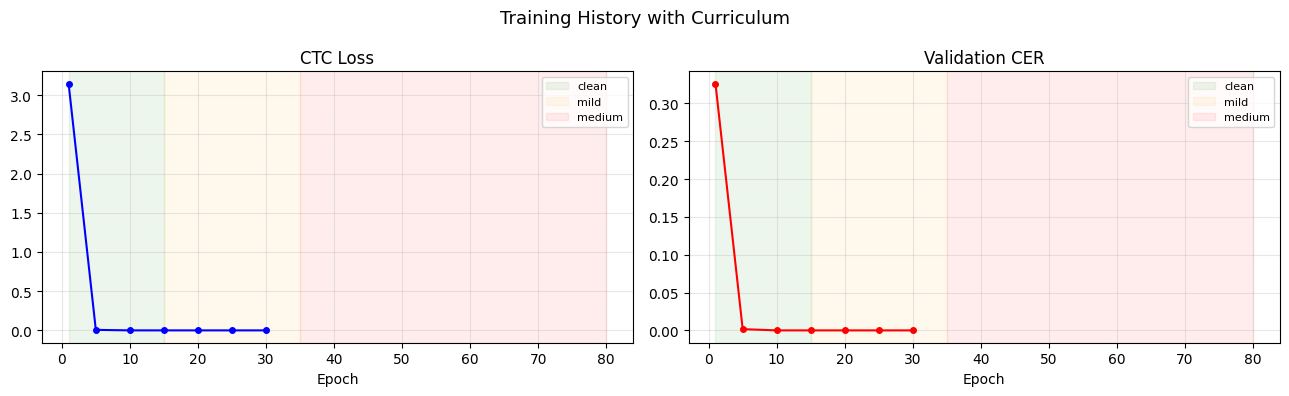

In [35]:
# Training curves
if history['cer']:
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(13,4))
    ax1.plot(history['epoch'],history['loss'],'b-o',ms=4)
    ax1.set_title('CTC Loss'); ax1.set_xlabel('Epoch'); ax1.grid(True,alpha=0.3)
    ax2.plot(history['epoch'],history['cer'],'r-o',ms=4)
    ax2.set_title('Validation CER'); ax2.set_xlabel('Epoch'); ax2.grid(True,alpha=0.3)
    # Shade curriculum phases
    for ax in [ax1,ax2]:
        ax.axvspan(1, 15, alpha=0.07, color='green', label='clean')
        ax.axvspan(15,35, alpha=0.07, color='orange',label='mild')
        ax.axvspan(35,80, alpha=0.07, color='red',   label='medium')
        ax.legend(fontsize=8)
    plt.suptitle('Training History with Curriculum', fontsize=13)
    plt.tight_layout(); plt.show()


---
## Phase 6 — Evaluation & Full Pipeline


✅ Synthetic model loaded


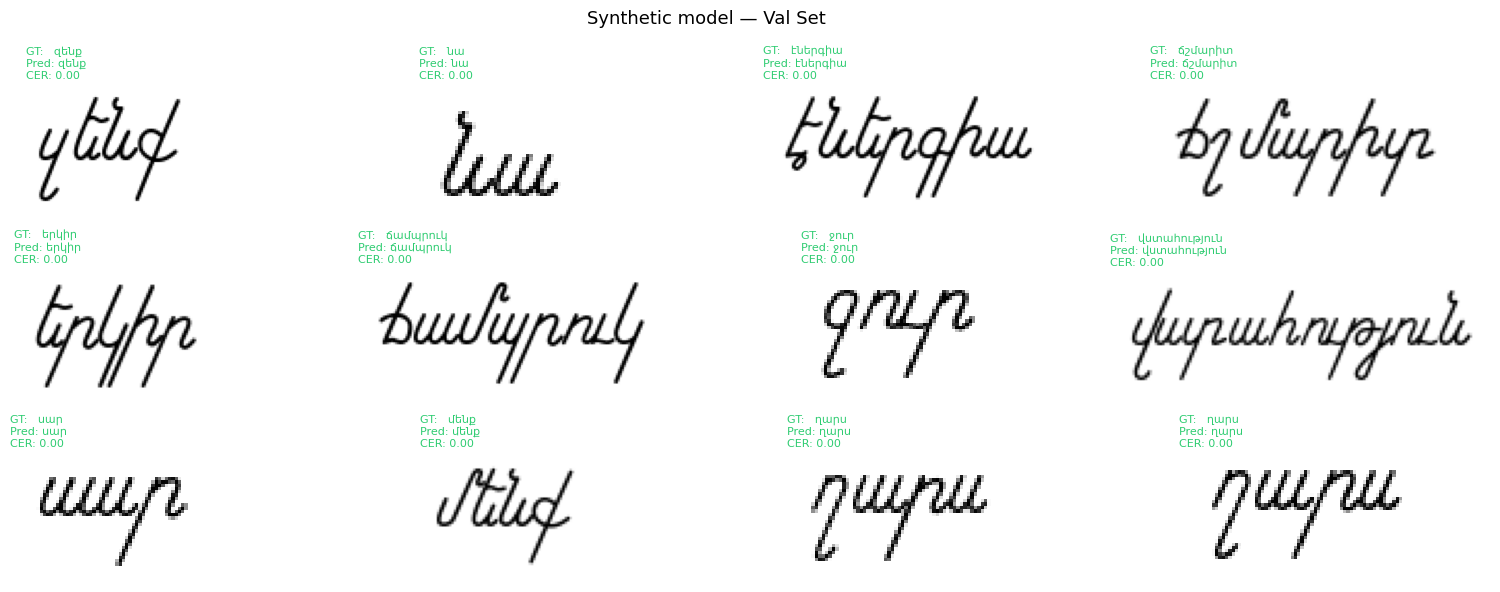

In [36]:
CKPT_DIR = Path('./checkpoints'); CKPT_DIR.mkdir(exist_ok=True)

def load_crnn(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    tok  = CTCTokenizer(ckpt['alphabet'])
    m    = CRNN(num_classes=ckpt['num_classes'], hidden_size=ckpt['hidden_size']).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    return m, tok

def predict_word(model, tokenizer, img_or_path, device, img_h=None):
    if img_h is None: img_h = IMG_HEIGHT
    if isinstance(img_or_path, (str, Path)):
        img = Image.open(img_or_path).convert('RGB')
    else:
        img = img_or_path.convert('RGB')
    w, h = img.size
    img  = img.resize((max(4, int(w * img_h / h)), img_h), Image.BILINEAR)
    tfm  = transforms.Compose([
        transforms.Grayscale(1),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    with torch.no_grad():
        return tokenizer.decode_batch(model(tfm(img).unsqueeze(0).to(device)))[0]

# Show synthetic val predictions
best_model, best_tok = load_crnn(str(CKPT_DIR / 'best_model.pt'), device)
print('✅ Synthetic model loaded')

n_show = min(12, len(val_df))
fig, axes = plt.subplots(3, 4, figsize=(16, 6))
for i, ax in enumerate(axes.flatten()[:n_show]):
    row  = val_df.iloc[i]
    pred = predict_word(best_model, best_tok, row['crop_path'], device)
    gt   = row['text']
    c    = cer_score(pred, gt)
    ax.imshow(Image.open(row['crop_path']).convert('L'), cmap='gray')
    color = '#2ecc71' if c==0 else ('#f39c12' if c<0.3 else '#e74c3c')
    ax.set_title(f'GT:   {gt}\nPred: {pred}\nCER: {c:.2f}',
                  color=color, fontsize=8, loc='left')
    ax.axis('off')
for ax in axes.flatten()[n_show:]: ax.axis('off')
plt.suptitle('Synthetic model — Val Set', fontsize=13)
plt.tight_layout(); plt.show()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


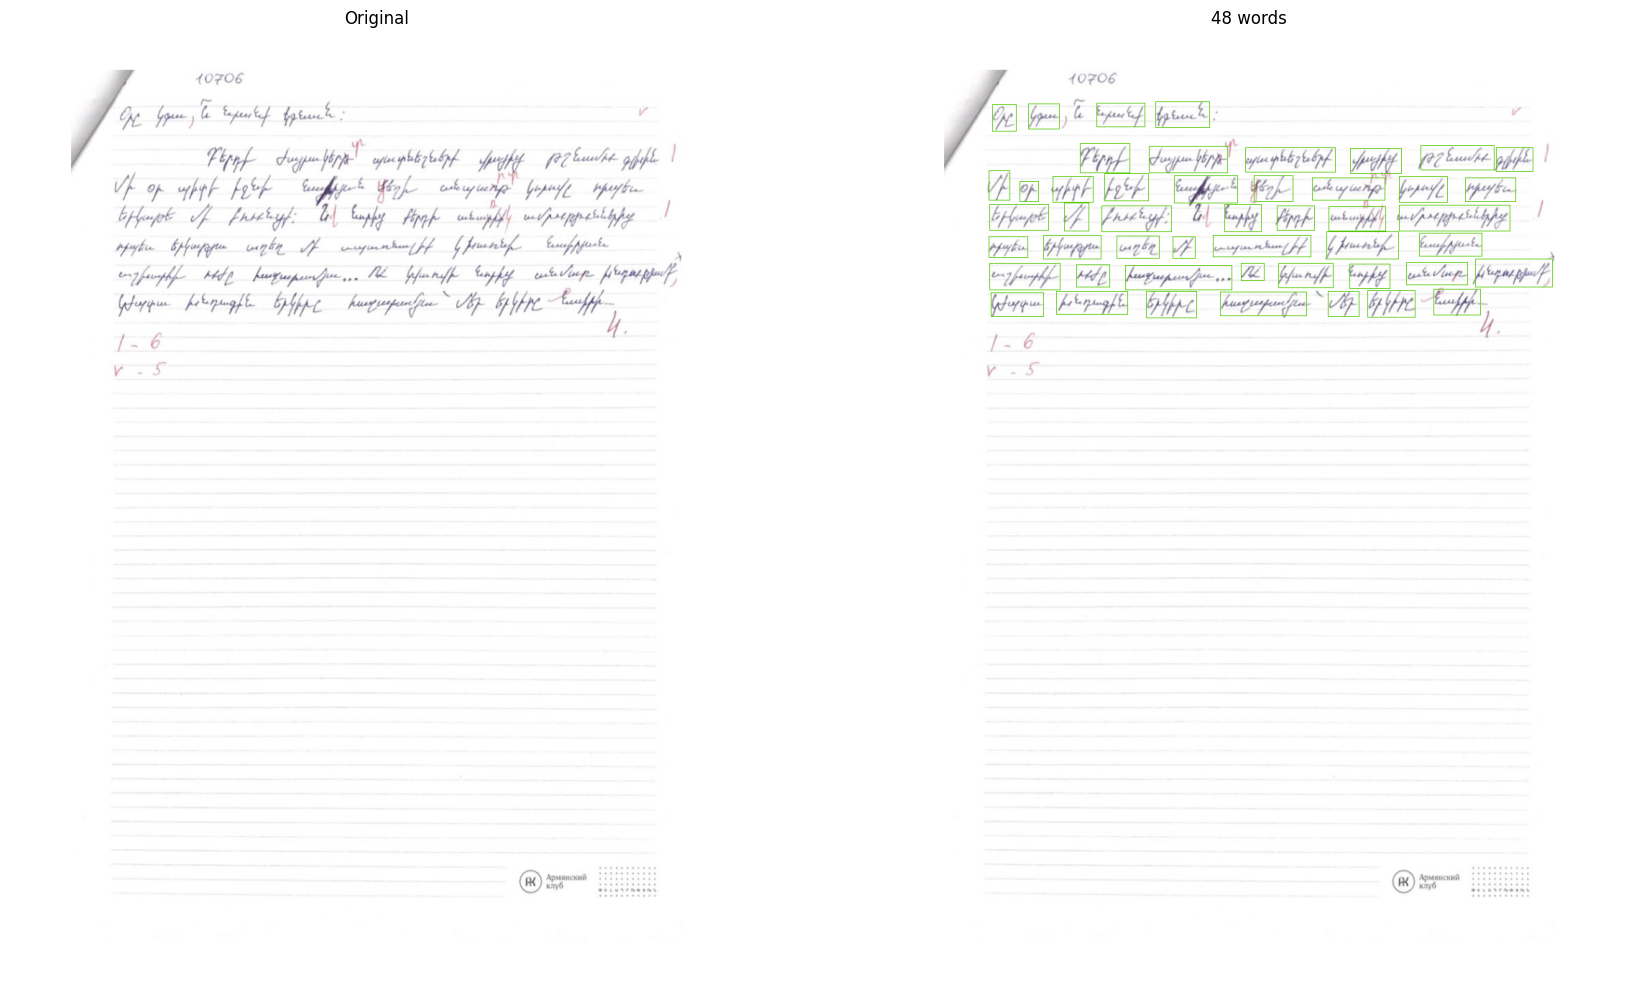


📄 Recognised text:

ո կու ու տու
Որ ոոո ոոր ոլ ոոոո ոո
 որ ո րռ աու օռ ռուուուո կու ոո
հոու ո ոու ու որ ոու ուուոո
ու օոոուու ու ու ուոոու րոոռոււ ուուո
ու ոռուո ռոուու ոո հոռուուու էոոււ ու ուոոռւ
կոո ոոո էոկոո ոոռուուոու ո օոո Հո


In [37]:
from ultralytics import YOLO
import cv2

def run_full_ocr(image_path, detector, recognizer, tokenizer, device,
                 conf=0.5, img_h=None, padding=3):
    if img_h is None: img_h = IMG_HEIGHT
    img    = Image.open(image_path).convert('RGB')
    W,H    = img.size
    img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    results = detector.predict(source=image_path, conf=conf, verbose=False)
    boxes   = results[0].boxes.xyxy.cpu().numpy()
    if len(boxes)==0: print('⚠ No words detected'); return img,[],[]
    boxes_sorted = sorted(boxes, key=lambda b:(round((b[1]+b[3])/2/25),b[0]))
    tfm = transforms.Compose([transforms.Grayscale(1),transforms.ToTensor(),transforms.Normalize([0.5],[0.5])])
    recognizer.eval(); word_results=[]
    with torch.no_grad():
        for box in boxes_sorted:
            x1,y1,x2,y2 = map(int,box)
            x1c,y1c = max(0,x1-padding),max(0,y1-padding)
            x2c,y2c = min(W,x2+padding),min(H,y2+padding)
            crop = img.crop((x1c,y1c,x2c,y2c))
            wc,hc = crop.size
            crop  = crop.resize((max(4,int(wc*img_h/hc)),img_h),Image.BILINEAR)
            text  = tokenizer.decode_batch(recognizer(tfm(crop).unsqueeze(0).to(device)))[0]
            word_results.append((box,text))
            cv2.rectangle(img_cv,(x1,y1),(x2,y2),(0,200,80),1)
    lines,cur_line,prev_y = [],[],-1
    for (x1,y1,x2,y2),text in word_results:
        cy=(y1+y2)/2
        if prev_y>=0 and abs(cy-prev_y)>20: lines.append(' '.join(cur_line)); cur_line=[]
        cur_line.append(text); prev_y=cy
    if cur_line: lines.append(' '.join(cur_line))
    ann = Image.fromarray(cv2.cvtColor(img_cv,cv2.COLOR_BGR2RGB))
    return ann, word_results, '\n'.join(lines)

detector    = YOLO(DETECTOR_PATH)
test_images = sorted(p for p,_,s in pairs if s=='test')
if test_images:
    ann_img, word_results, text = run_full_ocr(
        str(test_images[0]), detector, best_model, best_tok, device)
    fig,axes = plt.subplots(1,2,figsize=(18,10))
    axes[0].imshow(Image.open(test_images[0])); axes[0].set_title('Original'); axes[0].axis('off')
    axes[1].imshow(ann_img); axes[1].set_title(f'{len(word_results)} words'); axes[1].axis('off')
    plt.tight_layout(); plt.show()
    print('\n📄 Recognised text:\n'); print(text)


In [38]:
# Save synthetic model as final checkpoint for fine-tuning
torch.save({
    'model_state_dict': best_model.state_dict(),
    'alphabet':         ALL_CHARS,
    'num_classes':      tokenizer.num_classes,
    'hidden_size':      256,
    'img_height':       IMG_HEIGHT,
}, '/kaggle/working/checkpoints/synthetic_model.pt')
print('✅ Saved synthetic model → /kaggle/working/checkpoints/synthetic_model.pt')


✅ Saved synthetic model → /kaggle/working/checkpoints/synthetic_model.pt


In [42]:
pd.read_csv(CSV_A)

,crop_path,text
0,real_crops/train/8878901d-3389_conv_1_w0049.png,բլուրի
1,real_crops/train/8878901d-3389_conv_1_w0050.png,նախ
2,real_crops/train/8878901d-3389_conv_1_w0051.png,վրա
3,real_crops/train/8878901d-3389_conv_1_w0052.png,նստել
4,real_crops/train/8878901d-3389_conv_1_w0053.png,է
...,...,...
4678,real_crops/test/73790361-10719_conv_1_w0115.png,ա
4679,real_crops/test/73790361-10719_conv_1_w0116.png,բերդը
4680,real_crops/test/73790361-10719_conv_1_w0117.png,հանձնել
4681,real_crops/test/73790361-10719_conv_1_w0118.png,UNCLEAR


In [43]:
# ══════════════════════════════════════════════════════════════
# PHASE 7 — FINE-TUNE ON REAL LABELED DATA
# ══════════════════════════════════════════════════════════════

# ── Step 1: Load verified labeled data ────────────────────────
# Try verified CSV first, fall back to raw person CSVs
CSV_A = '/kaggle/input/datasets/araksyag/des-den/labels_ia (1).csv'
CSV_B        = '/kaggle/input/datasets/araksyag/des-den/labels_person_B (4).csv'

print('⚠ Verified CSV not found — merging raw person files')
df_a   = pd.read_csv(CSV_A)
df_b   = pd.read_csv(CSV_B)
merged = pd.concat([df_a, df_b], ignore_index=True)
print(f'   Person A: {len(df_a)}  +  Person B: {len(df_b)}')

# Clean
merged = merged[merged['text'].notna()]
merged = merged[merged['text'].str.strip() != '']
merged = merged[merged['text'] != 'UNCLEAR']
merged = merged.drop_duplicates(subset='crop_path', keep='first')

# Fix relative paths → absolute
merged['crop_path'] = merged['crop_path'].apply(
    lambda p: str(Path('/kaggle/working') / p)
              if not str(p).startswith('/') else p
)

# Remove missing files
missing = ~merged['crop_path'].apply(lambda p: Path(p).exists())
if missing.sum() > 0:
    print(f'⚠ Removing {missing.sum()} missing files')
    merged = merged[~missing]

merged = merged.reset_index(drop=True)
print(f'Dataset after cleaning: {len(merged)} samples')


⚠ Verified CSV not found — merging raw person files
   Person A: 4683  +  Person B: 2814
Dataset after cleaning: 4019 samples


Crops before filter: 4019
Crops after filter:  2755  (1264 removed)
Train: 2341  |  Val: 414


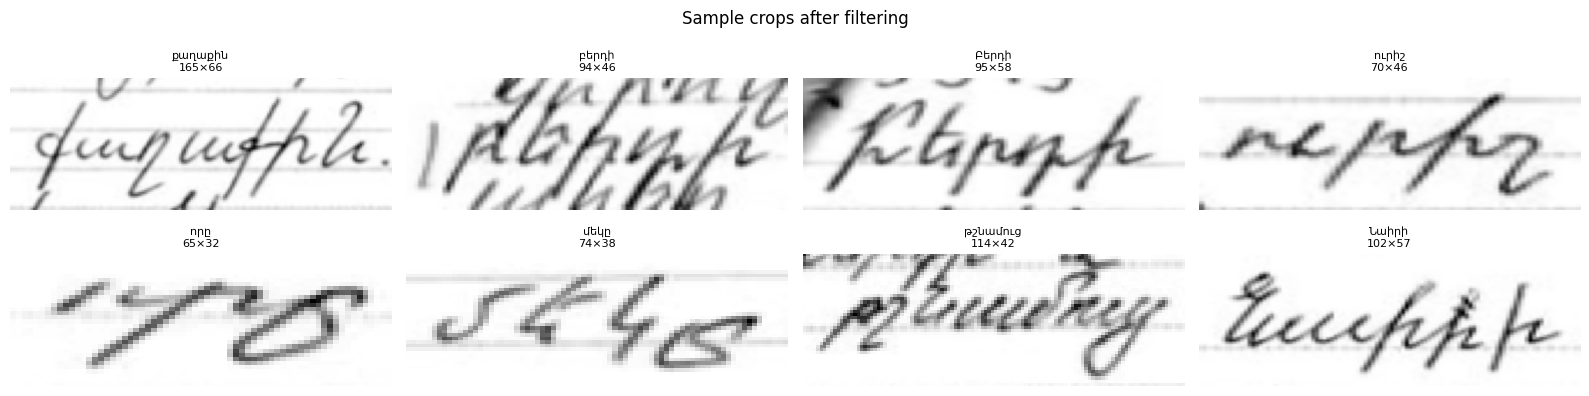

In [47]:
# ── Step 2: Filter bad crops (multi-line, blank, too small) ──
def is_valid_word_crop(path):
    try:
        img  = Image.open(path).convert('L')
        w, h = img.size
        if w / h < 1.5:          return False  # too tall = multi-line
        if h < 15 or h > 100:    return False  # wrong height range
        if w > 800:               return False  # too wide = full line
        arr = np.array(img, dtype=np.float32)
        if np.mean(arr < 200) < 0.03: return False  # mostly white
        return True
    except:
        return False

before   = len(merged)
filtered = merged[merged['crop_path'].apply(is_valid_word_crop)].reset_index(drop=True)
after    = len(filtered)
print(f'Crops before filter: {before}')
print(f'Crops after filter:  {after}  ({before-after} removed)')

# ── Step 3: Split train / val ─────────────────────────────────
filtered  = filtered.sample(frac=1, random_state=42).reset_index(drop=True)
cut       = int(len(filtered) * 0.85)
ft_train_df = filtered.iloc[:cut].reset_index(drop=True)
ft_val_df   = filtered.iloc[cut:].reset_index(drop=True)
print(f'Train: {len(ft_train_df)}  |  Val: {len(ft_val_df)}')

# Show sample crops
sample_paths = filtered['crop_path'].sample(min(8, len(filtered)), random_state=1).tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 4))
for ax, path in zip(axes.flatten(), sample_paths):
    img  = Image.open(path).convert('L')
    w, h = img.size
    text = filtered[filtered['crop_path']==path]['text'].values[0]
    ax.imshow(img, cmap='gray', aspect='auto')
    ax.set_title(f'{text}\n{w}×{h}', fontsize=8)
    ax.axis('off')
for ax in axes.flatten()[len(sample_paths):]: ax.axis('off')
plt.suptitle('Sample crops after filtering', fontsize=12)
plt.tight_layout(); plt.show()

# ── Step 4: Build DataLoaders ─────────────────────────────────
ft_train_ds = ArmOCRDataset(ft_train_df, tokenizer, augment=True)
ft_val_ds   = ArmOCRDataset(ft_val_df,   tokenizer, augment=False)

ft_train_loader = DataLoader(ft_train_ds, batch_size=16, shuffle=True,
                              collate_fn=collate_fn, num_workers=2)
ft_val_loader   = DataLoader(ft_val_ds,   batch_size=16, shuffle=False,
                              collate_fn=collate_fn, num_workers=2)


In [45]:
# ── Step 5: Load synthetic-pretrained model ──────────────────
SYNTHETIC_MODEL = '/kaggle/working/checkpoints/synthetic_model.pt'

model, tokenizer = load_crnn(SYNTHETIC_MODEL, device)
print(f'✅ Loaded synthetic model from {SYNTHETIC_MODEL}')

# Check prediction before fine-tuning
sample      = ft_val_df.iloc[0]
pred_before = predict_word(model, tokenizer, sample['crop_path'], device)
print(f'Before fine-tuning:')
print(f'  GT:   "{sample["text"]}"')
print(f'  Pred: "{pred_before}"')


✅ Loaded synthetic model from /kaggle/working/checkpoints/synthetic_model.pt
Before fine-tuning:
  GT:   "անառի"
  Pred: "ոո"


Fine-tuning: 2341 train / 414 val
Max epochs: 150  |  Early stop patience: 10
───────────────────────────────────────────────────────
Epoch 001  loss=2.8531  CER=0.4852  lr=1.0e-04  patience=0/10
   ✗  GT="անառի"  →  Pred="առիկ"
   ✗  GT="քարե"  →  Pred="քարը"
   ✗  GT="նորից"  →  Pred="նր"
   ✗  GT="սպառնալի"  →  Pred="ապանայիք"
   💾 Best (CER=0.4852)
Epoch 005  loss=1.0498  CER=0.2475  lr=1.0e-04  patience=0/10
   ✗  GT="անառի"  →  Pred="ամառիկ"
   ✓  GT="քարե"  →  Pred="քարե"
   ✗  GT="նորից"  →  Pred="նորց"
   ✗  GT="սպառնալի"  →  Pred="պպառնալիք"
   💾 Best (CER=0.2475)
Epoch 010  loss=0.5776  CER=0.1778  lr=9.9e-05  patience=0/10
   ✗  GT="անառի"  →  Pred="ամառիկ"
   ✗  GT="քարե"  →  Pred="Քաը"
   ✓  GT="նորից"  →  Pred="նորից"
   ✗  GT="սպառնալի"  →  Pred="պառնալիք"
   💾 Best (CER=0.1778)
Epoch 015  loss=0.3754  CER=0.1361  lr=9.8e-05  patience=0/10
   ✗  GT="անառի"  →  Pred="անառիկ"
   ✓  GT="քարե"  →  Pred="քարե"
   ✗  GT="նորից"  →  Pred="նրից"
   ✗  GT="սպառնալի"  →  Pred="պա

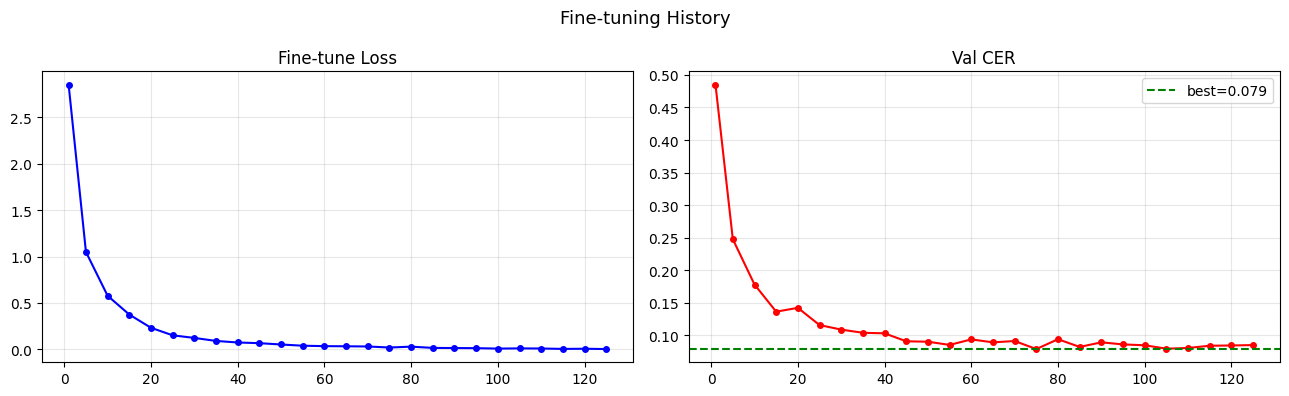

In [48]:
# ── Step 6: Fine-tune ────────────────────────────────────────
FINETUNE_EPOCHS = 150
LR              = 1e-4
PATIENCE        = 10    # stop if no improvement for 20 evals

ft_optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=2e-4)
ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(
                   ft_optimizer, T_max=FINETUNE_EPOCHS, eta_min=1e-7)
ctc_loss     = nn.CTCLoss(blank=tokenizer.blank_idx,
                           reduction='mean', zero_infinity=True)

best_ft_cer   = float('inf')
epochs_no_imp = 0
ft_history    = {'epoch': [], 'loss': [], 'cer': []}

print(f'Fine-tuning: {len(ft_train_ds)} train / {len(ft_val_ds)} val')
print(f'Max epochs: {FINETUNE_EPOCHS}  |  Early stop patience: {PATIENCE}')
print('─' * 55)

for epoch in range(1, FINETUNE_EPOCHS + 1):
    model.train()
    epoch_loss, n_ok = 0.0, 0

    for imgs, lbls, ll in ft_train_loader:
        imgs, lbls, ll = imgs.to(device), lbls.to(device), ll.to(device)
        ft_optimizer.zero_grad()
        log_probs        = model(imgs)
        seq_len, B, _    = log_probs.shape
        input_lengths    = torch.full((B,), seq_len, dtype=torch.long, device=device)
        loss = ctc_loss(log_probs, lbls, input_lengths, ll)
        if torch.isfinite(loss):
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            ft_optimizer.step()
            epoch_loss += loss.item()
            n_ok       += 1

    ft_scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        val_cer, examples = evaluate(model, ft_val_loader,
                                     tokenizer, device, max_batches=None)
        avg_loss = epoch_loss / max(n_ok, 1)
        ft_history['epoch'].append(epoch)
        ft_history['loss'].append(avg_loss)
        ft_history['cer'].append(val_cer)

        print(f'Epoch {epoch:03d}  loss={avg_loss:.4f}  CER={val_cer:.4f}  '
              f'lr={ft_scheduler.get_last_lr()[0]:.1e}  '
              f'patience={epochs_no_imp}/{PATIENCE}')
        for gt, pred in examples[:4]:
            print(f'   {"✓" if gt==pred else "✗"}  GT="{gt}"  →  Pred="{pred}"')

        if val_cer < best_ft_cer - 0.001:
            best_ft_cer   = val_cer
            epochs_no_imp = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'alphabet':         ALL_CHARS,
                'num_classes':      tokenizer.num_classes,
                'hidden_size':      256,
                'img_height':       IMG_HEIGHT,
            }, '/kaggle/working/checkpoints/finetuned_model.pt')
            print(f'   💾 Best (CER={best_ft_cer:.4f})')
        else:
            epochs_no_imp += 1
            if epochs_no_imp >= PATIENCE:
                print(f'\n⏹ Early stop at epoch {epoch}')
                break

print(f'\n✅ Fine-tuning done. Best CER: {best_ft_cer:.4f}')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(ft_history['epoch'], ft_history['loss'], 'b-o', ms=4)
ax1.set_title('Fine-tune Loss'); ax1.grid(True, alpha=0.3)
ax2.plot(ft_history['epoch'], ft_history['cer'],  'r-o', ms=4)
ax2.axhline(best_ft_cer, color='green', linestyle='--',
            label=f'best={best_ft_cer:.3f}')
ax2.set_title('Val CER'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.suptitle('Fine-tuning History', fontsize=13)
plt.tight_layout(); plt.show()


✅ Fine-tuned model loaded


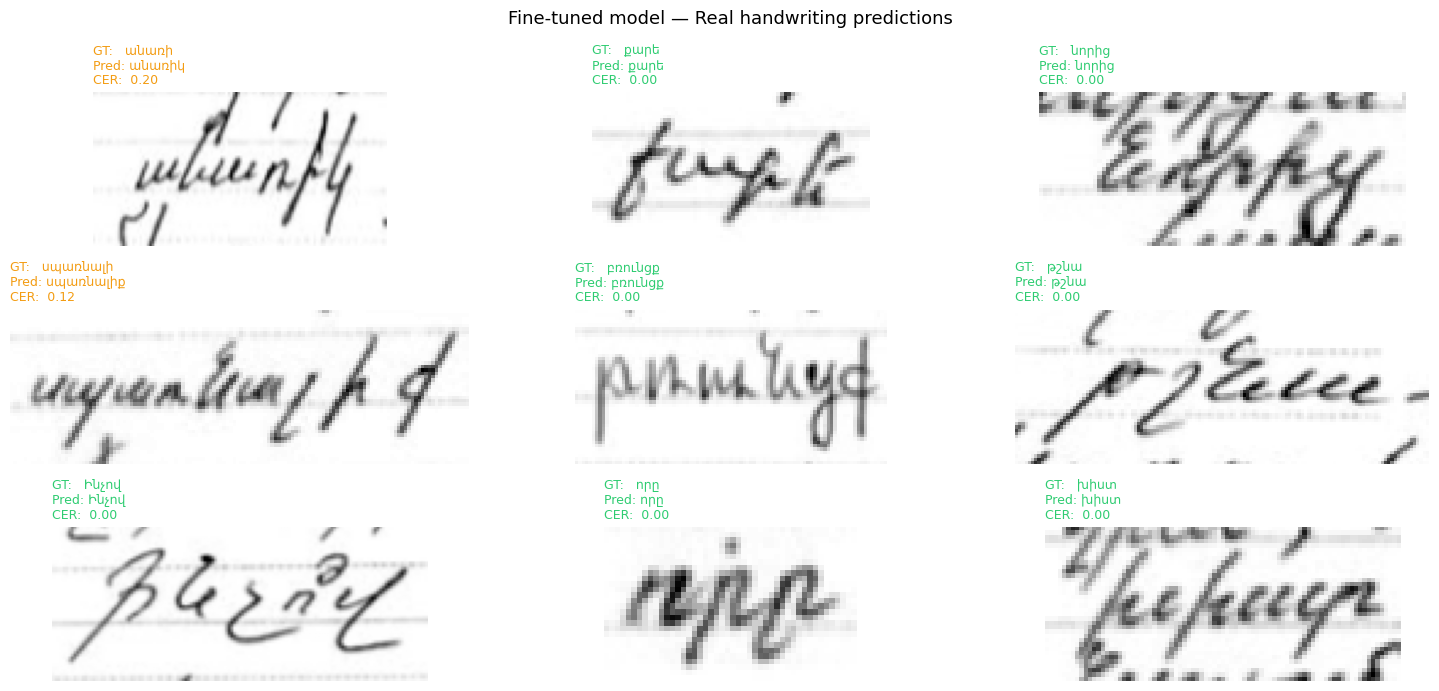


Val set CER: 0.0775  (296/414 exact matches)


In [49]:
# ── Step 7: Evaluate fine-tuned model ────────────────────────
best_model, best_tok = load_crnn(
    '/kaggle/working/checkpoints/finetuned_model.pt', device)
print('✅ Fine-tuned model loaded')

n_show = min(9, len(ft_val_df))
fig, axes = plt.subplots(3, 3, figsize=(15, 7))
for i, ax in enumerate(axes.flatten()[:n_show]):
    row  = ft_val_df.iloc[i]
    pred = predict_word(best_model, best_tok, row['crop_path'], device)
    gt   = row['text']
    c    = cer_score(pred, gt)
    ax.imshow(Image.open(row['crop_path']).convert('L'), cmap='gray')
    color = '#2ecc71' if c==0 else ('#f39c12' if c<0.4 else '#e74c3c')
    ax.set_title(f'GT:   {gt}\nPred: {pred}\nCER:  {c:.2f}',
                 color=color, fontsize=9, loc='left')
    ax.axis('off')
for ax in axes.flatten()[n_show:]: ax.axis('off')
plt.suptitle('Fine-tuned model — Real handwriting predictions', fontsize=13)
plt.tight_layout(); plt.show()

# Overall CER on full val set
all_cer = []
for _, row in ft_val_df.iterrows():
    pred = predict_word(best_model, best_tok, row['crop_path'], device)
    all_cer.append(cer_score(pred, row['text']))
print(f'\nVal set CER: {sum(all_cer)/len(all_cer):.4f}  '
      f'({sum(1 for c in all_cer if c==0)}/{len(all_cer)} exact matches)')


Detected 48 words


/tmp/ipykernel_57/1147948247.py:62: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


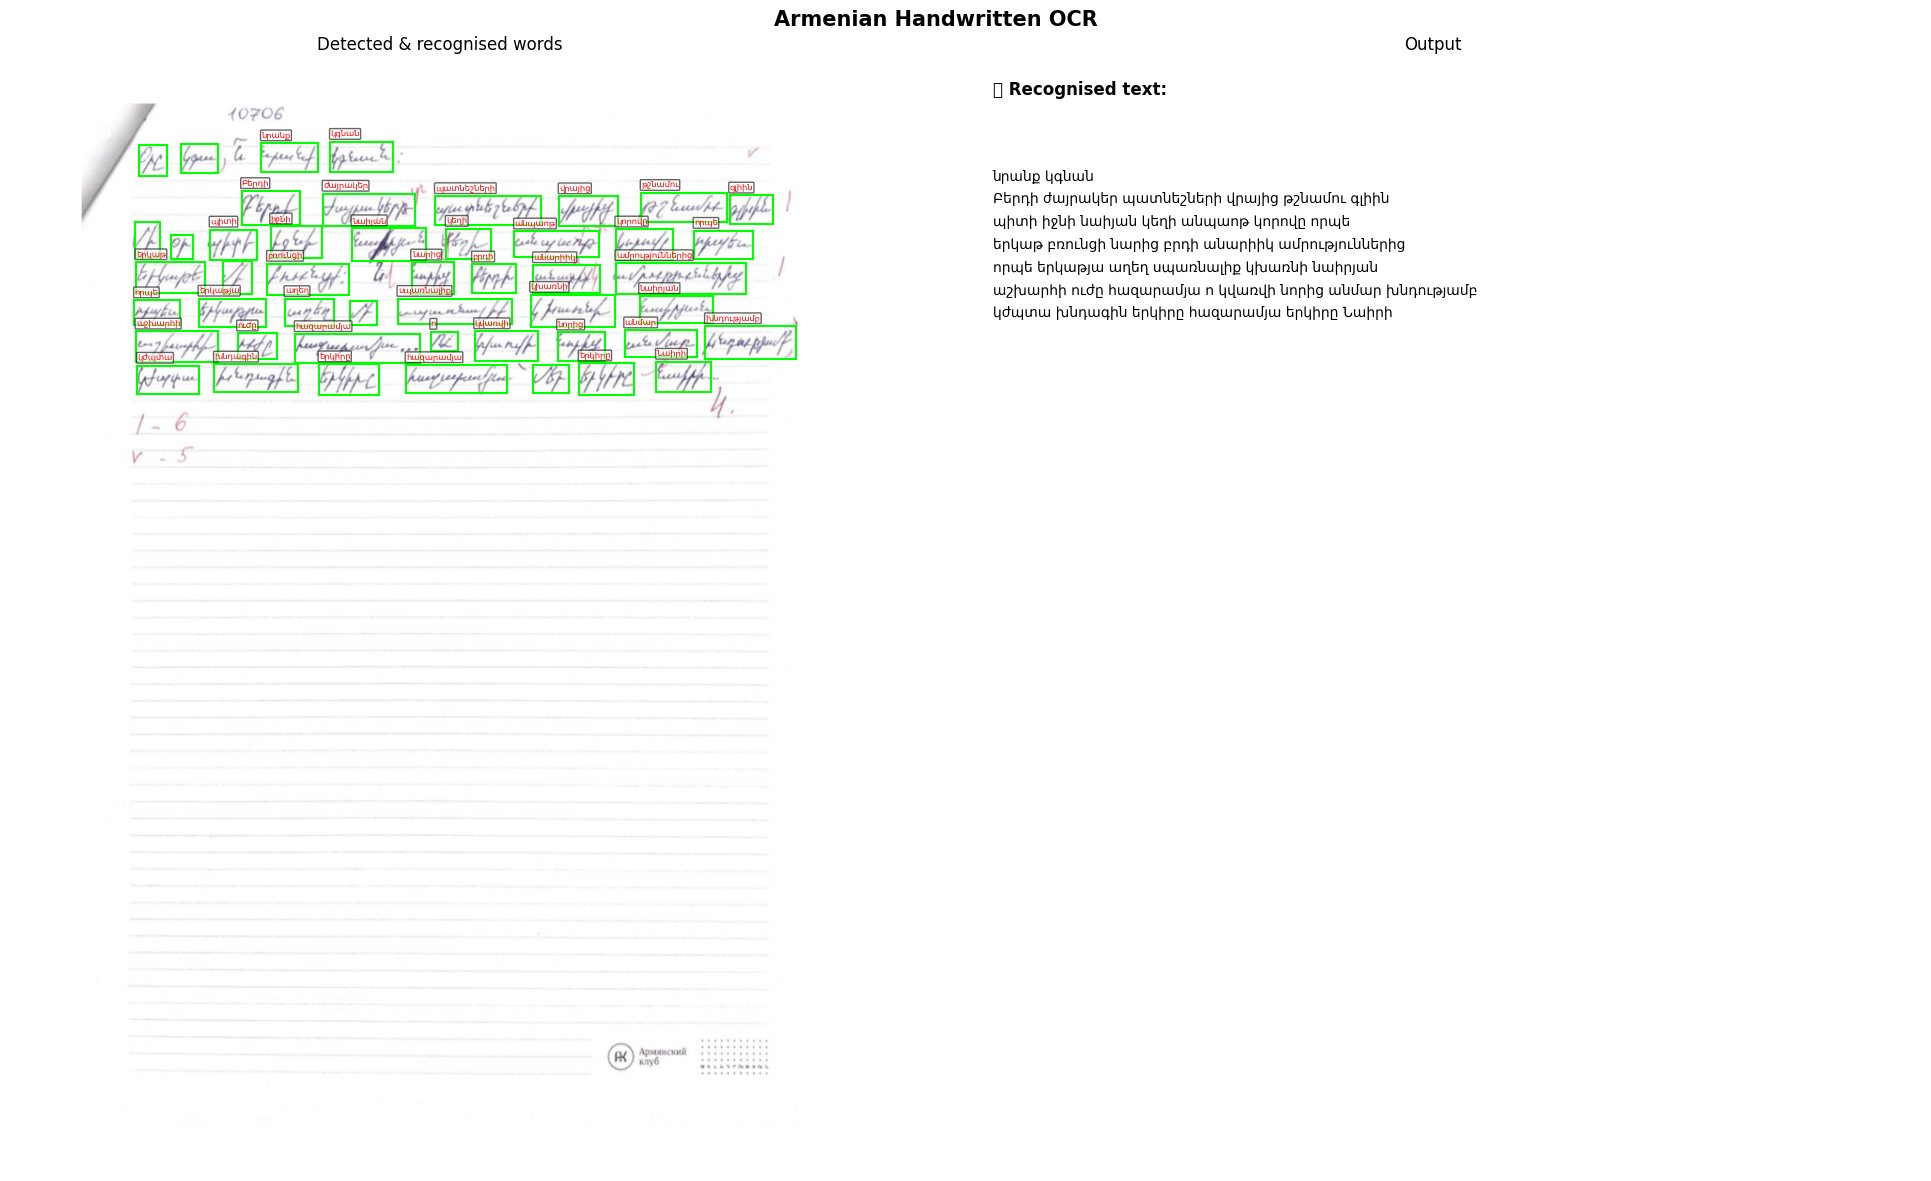


📄 Full text:
 նրանք կգնան
Բերդի ժայրակեր պատնեշների վրայից թշնամու գլիին
պիտի իջնի նաիյան կեղի անպաոթ կորովը որպե
երկաթ բռունցի նարից բրդի անարիիկ ամրություններից
որպե երկաթյա աղեղ սպառնալիք կխառնի նաիրյան
աշխարհի ուժը հազարամյա ո կվառվի նորից անմար խնդությամբ
կժպտա խնդագին երկիրը հազարամյա երկիրը Նաիրի


In [50]:
# ── Step 8: Full pipeline demo ───────────────────────────────
from ultralytics import YOLO

# ↓ Change to your test image
IMAGE_PATH = '/kaggle/working/handwritten_text_detection/test/images'
test_images = sorted(Path(IMAGE_PATH).glob('*.jpg')) +               sorted(Path(IMAGE_PATH).glob('*.png'))

if not test_images:
    print('No test images found — set IMAGE_PATH to your image')
else:
    img_path = str(test_images[0])
    detector = YOLO(DETECTOR_PATH)
    img      = Image.open(img_path).convert('RGB')
    W, H     = img.size

    results      = detector.predict(source=img_path, conf=0.4, verbose=False)
    boxes        = results[0].boxes.xyxy.cpu().numpy()
    boxes_sorted = sorted(boxes, key=lambda b: (round((b[1]+b[3])/2/30), b[0]))
    print(f'Detected {len(boxes_sorted)} words')

    word_results = []
    for box in boxes_sorted:
        x1,y1,x2,y2 = map(int, box)
        crop = img.crop((max(0,x1-4), max(0,y1-4),
                         min(W,x2+4), min(H,y2+4)))
        # Only predict on valid word-shaped crops
        w,h = crop.size
        if w/max(h,1) > 1.2 and h < 120:
            text = predict_word(best_model, best_tok, crop, device)
        else:
            text = ''
        word_results.append((box, text))

    # Assemble text
    lines, cur_line, prev_y = [], [], -1
    for (x1,y1,x2,y2), text in word_results:
        cy = (y1+y2)/2
        if prev_y >= 0 and abs(cy-prev_y) > 25:
            lines.append(' '.join(cur_line)); cur_line=[]
        if text.strip(): cur_line.append(text)
        prev_y = cy
    if cur_line: lines.append(' '.join(cur_line))
    full_text = '\n'.join(lines)

    # Visualise
    fig, axes = plt.subplots(1, 2, figsize=(20, 12))
    axes[0].imshow(img)
    for (x1,y1,x2,y2), text in word_results:
        axes[0].add_patch(patches.Rectangle(
            (x1,y1), x2-x1, y2-y1, lw=1.5, edgecolor='lime', facecolor='none'))
        if text:
            axes[0].text(x1, y1-4, text, color='red', fontsize=6, va='bottom',
                         bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6))
    axes[0].set_title('Detected & recognised words'); axes[0].axis('off')
    axes[1].axis('off')
    axes[1].text(0.05, 0.98, '📄 Recognised text:', transform=axes[1].transAxes,
                 fontsize=12, fontweight='bold', va='top')
    axes[1].text(0.05, 0.90, full_text or '(nothing recognised)',
                 transform=axes[1].transAxes, fontsize=10, va='top', linespacing=1.8)
    axes[1].set_title('Output')
    plt.suptitle('Armenian Handwritten OCR', fontsize=15, fontweight='bold')
    plt.tight_layout(); plt.show()
    print('\n📄 Full text:\n', full_text)


In [51]:
import shutil
shutil.copy('/kaggle/working/checkpoints/finetuned_model.pt',
            '/kaggle/working/finetuned_model.pt')

from IPython.display import FileLink
display(FileLink('/kaggle/working/finetuned_model.pt'))
print('✅ Download link above')


/kaggle/working/finetuned_model.pt

✅ Download link above


In [52]:
from IPython.display import FileLink
display(FileLink('/kaggle/working/finetuned_model.pt'))
print('✅ Download link above')

/kaggle/working/finetuned_model.pt

✅ Download link above
